In [1]:

import numpy as np
import matplotlib.pyplot as plt


In [2]:


# =========================
# 1. GINI IMPURITY
# =========================

def gini(y):
    if len(y) == 0:
        return 0
    p = np.mean(y)
    return 1 - (p**2 + (1 - p)**2)


In [4]:


# =========================
# 2. SPLIT DATA
# =========================

def split(X, y, feature, threshold):
    
    left_mask  = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold
    
    return X[left_mask], X[right_mask], y[left_mask], y[right_mask]



In [5]:

# =========================
# 3. SPLIT SCORE
# =========================

def split_score(y_left, y_right):
    
    n   = len(y_left) + len(y_right)
    
    
    return (len(y_left)/n)*gini(y_left) + (len(y_right)/n)*gini(y_right)



In [6]:

# =========================
# 4. FIND BEST SPLIT
# =========================

def best_split(X, y):
    
    best_feature   = None
    best_threshold = None
    best_score     = 1e9
    
    n_features     = X.shape[1]
    
    for feature in range(n_features):
        
        thresholds = np.unique(  X[:, feature]  )
        
        for t in thresholds:
            
            _, _, y_left, y_right = split(X, y, feature, t)
            
            if len(y_left) == 0 or len(y_right) == 0:
                continue
            
            score = split_score(y_left, y_right)
            
            if score < best_score:
                best_score     = score
                best_feature   = feature
                best_threshold = t
    
    return best_feature, best_threshold


In [7]:

# =========================
# 5. BUILD TREE (RECURSIVE)
# =========================

class Node:
    
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature   = feature
        self.threshold = threshold
        self.left      = left
        self.right     = right
        self.value     = value  # leaf


In [8]:


def build_tree(X, y, depth=0, max_depth=3):
    
    # stop conditions
    if len(set(y)) == 1:
        return Node(value=y[0])
    
    if depth >= max_depth:
        return Node(value=int(np.round(np.mean(y))))
    
    feature, threshold = best_split(X, y)
    
    if feature is None:
        return Node(value=int(np.round(np.mean(y))))
    
    X_l, X_r, y_l, y_r = split(X, y, feature, threshold)
    
    left  = build_tree(X_l, y_l, depth+1, max_depth)
    right = build_tree(X_r, y_r, depth+1, max_depth)
    
    return Node(feature, threshold, left, right)



In [9]:


# =========================
# 6. PREDICT
# =========================

def predict_one(node, x):
    
    if node.value is not None:
        return node.value
    
    if x[node.feature] <= node.threshold:
        return predict_one(node.left, x)
    else:
        return predict_one(node.right, x)



In [10]:

def predict(tree, X):
    return np.array([predict_one(tree, x) for x in X])


In [11]:


# =========================
# 7. SIMPLE DATA (NONLINEAR)
# =========================
np.random.seed(42)

from sklearn.datasets import make_moons

X, y = make_moons(n_samples=200, noise=0.2)


In [12]:


# =========================
# 8. TRAIN TREE
# =========================
tree = build_tree(X, y, max_depth=3)



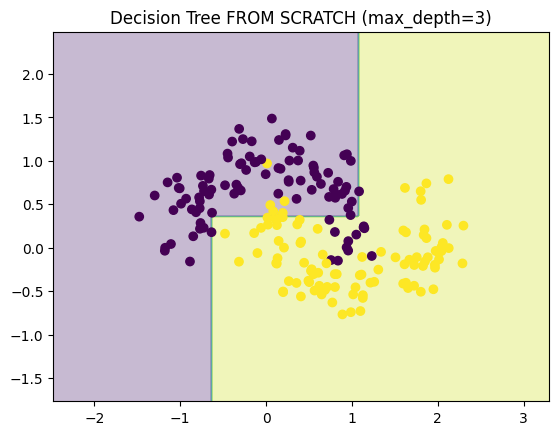

In [13]:

# =========================
# 9. PLOT DECISION BOUNDARY
# =========================
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = predict(tree, grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Decision Tree FROM SCRATCH (max_depth=3)")
plt.show()

